<a href="https://colab.research.google.com/github/TTharunsai/ITA0651ML/blob/main/ITA0651%20EXP-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your CSV dataset file


Saving finds_dataset.csv to finds_dataset (2).csv

Dataset Loaded Successfully:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High    Weak  Warm     Same        Yes

Most Specific Hypothesis:
['Sunny' 'Warm' '?' '?' 'Warm' 'Same']


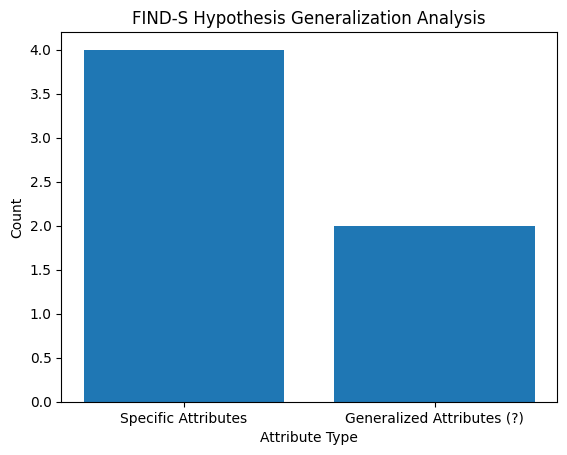

In [4]:
# ================================
# ALL-IN-ONE FIND-S IMPLEMENTATION
# File Upload + Algorithm + Graph
# ================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 2. Upload CSV file
print("Please upload your CSV dataset file")
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# 3. Read dataset
dataset = pd.read_csv(file_name)
print("\nDataset Loaded Successfully:\n")
print(dataset)

# 4. FIND-S Algorithm
def find_s(dataset):
    concepts = dataset.iloc[:, :-1].values
    target = dataset.iloc[:, -1].values

    # Initialize hypothesis with first positive example
    for i in range(len(target)):
        if target[i] == "Yes":
            hypothesis = concepts[i].copy()
            break

    # Generalize hypothesis
    for i in range(len(concepts)):
        if target[i] == "Yes":
            for j in range(len(hypothesis)):
                if concepts[i][j] != hypothesis[j]:
                    hypothesis[j] = '?'

    return hypothesis

# 5. Run FIND-S
final_hypothesis = find_s(dataset)

print("\nMost Specific Hypothesis:")
print(final_hypothesis)

# 6. Graphical Metric
# Count specific vs generalized attributes
specific_count = final_hypothesis.tolist().count('?')
exact_count = len(final_hypothesis) - specific_count

labels = ['Specific Attributes', 'Generalized Attributes (?)']
values = [exact_count, specific_count]

# 7. Plot graph
plt.figure()
plt.bar(labels, values)
plt.xlabel("Attribute Type")
plt.ylabel("Count")
plt.title("FIND-S Hypothesis Generalization Analysis")
plt.show()